In [43]:
pip install pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\mouly\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


IMPORT LIBRARIES

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

LOAD DATASET

In [45]:
car_sales = pd.read_csv("car_data.csv")

print(car_sales.head())
print(car_sales.columns)
print(car_sales.info())

         Car_id      Date Customer Name Gender  Annual Income  \
0  C_CND_000001  1/2/2022     Geraldine   Male          13500   
1  C_CND_000002  1/2/2022           Gia   Male        1480000   
2  C_CND_000003  1/2/2022        Gianna   Male        1035000   
3  C_CND_000004  1/2/2022       Giselle   Male          13500   
4  C_CND_000005  1/2/2022         Grace   Male        1465000   

                           Dealer_Name   Company       Model  \
0  Buddy Storbeck's Diesel Service Inc      Ford  Expedition   
1                     C & M Motors Inc     Dodge     Durango   
2                          Capitol KIA  Cadillac    Eldorado   
3               Chrysler of Tri-Cities    Toyota      Celica   
4                    Chrysler Plymouth     Acura          TL   

                      Engine Transmission       Color  Price ($)  Dealer_No   \
0  DoubleÂ Overhead Camshaft         Auto       Black      26000  06457-3834   
1  DoubleÂ Overhead Camshaft         Auto       Black      19000

CLEAN DATA

In [46]:
car_sales.drop_duplicates(inplace=True)
car_sales.fillna(0, inplace=True)

CREATE REVENUE COLUMN

In [47]:
car_sales['Revenue'] = car_sales['Price ($)']

CONVERT DATE COLUMN

In [48]:
car_sales['Date'] = pd.to_datetime(car_sales['Date'])

CREATE TIME FEATURES

In [49]:
car_sales['Month'] = car_sales['Date'].dt.month
car_sales['Year'] = car_sales['Date'].dt.year

MONTHLY SALES

In [50]:
monthly_sales = car_sales.groupby('Month')['Revenue'].sum()

print(monthly_sales)

Month
1     21696218
2     20643945
3     41705873
4     46864434
5     53221243
6     48505902
7     48178032
8     48793638
9     93635178
10    52035265
11    96979678
12    99266059
Name: Revenue, dtype: int64


COUNTRY ANALYSIS

In [52]:
car_sales.columns = car_sales.columns.str.strip()

In [54]:
print(car_sales.columns)

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No', 'Body Style', 'Phone', 'Dealer_Region',
       'Revenue', 'Month', 'Year'],
      dtype='object')


In [55]:
country_sales = car_sales.groupby('Dealer_Region')['Revenue'].sum()

print(country_sales)

Dealer_Region
Aurora         88687382
Austin        117192531
Greenville     88149602
Janesville    106351234
Middletown     87134628
Pasco          88040714
Scottsdale     95969374
Name: Revenue, dtype: int64


In [57]:
region_sales = car_sales.groupby('Dealer_Region')['Revenue'].sum()

print(region_sales)

Dealer_Region
Aurora         88687382
Austin        117192531
Greenville     88149602
Janesville    106351234
Middletown     87134628
Pasco          88040714
Scottsdale     95969374
Name: Revenue, dtype: int64


MODEL ANALYSIS

In [58]:
model_sales = car_sales.groupby('Model')['Revenue'].sum().sort_values(ascending=False)

print(model_sales.head(10))

Model
LS400            14263424
Jetta            12287736
Silhouette       12271849
Montero Sport    11472231
Ram Pickup       10655391
Eldorado          9725407
528i              9577927
Prizm             9386606
Diamante          9308151
LHS               9097717
Name: Revenue, dtype: int64


DEALER ANALYSIS

In [59]:
dealer_sales = car_sales.groupby('Dealer_Name')['Revenue'].sum().sort_values(ascending=False)

print(dealer_sales.head(10))

Dealer_Name
Rabun Used Car Sales                               37456655
Progressive Shippers Cooperative Association No    36751460
U-Haul CO                                          35876089
Race Car Help                                      35288706
Saab-Belle Dodge                                   35265865
Scrivener Performance Engineering                  35258525
Star Enterprises Inc                               35113206
Tri-State Mack Inc                                 35091357
Suburban Ford                                      34943473
Ryder Truck Rental and Leasing                     34837906
Name: Revenue, dtype: int64


VISUALIZATIONS

Country Chart

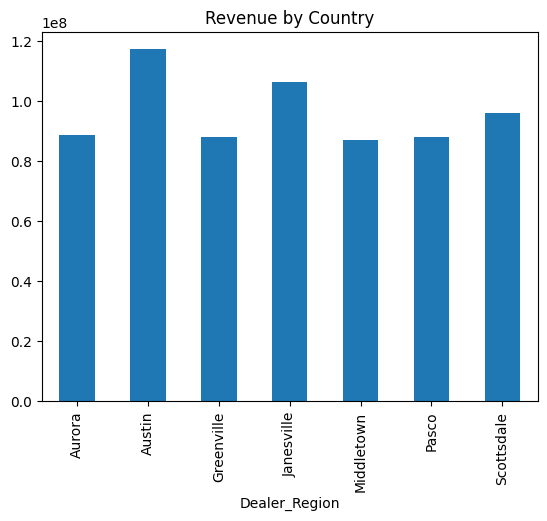

In [60]:
country_sales.plot(kind='bar')
plt.title("Revenue by Country")
plt.show()

Monthly Trend

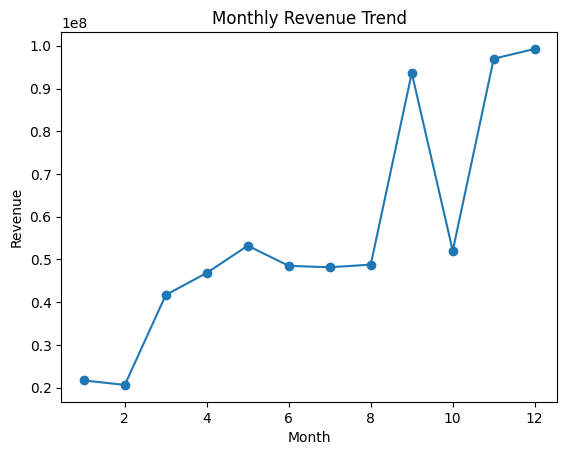

In [61]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Gender Analysis

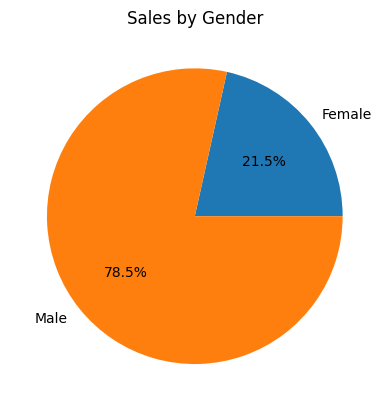

In [62]:
gender_sales = car_sales.groupby('Gender')['Revenue'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Gender")
plt.ylabel("")
plt.show()

Top Brands

In [67]:
brand_sales = car_sales.groupby('Company')['Revenue'].sum().sort_values(ascending=False)

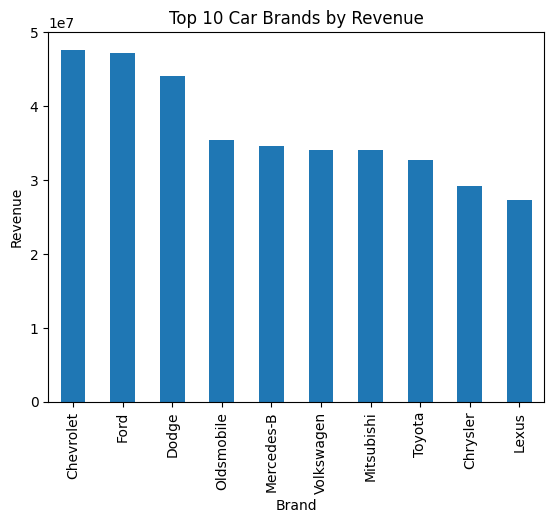

In [68]:
brand_sales.head(10).plot(kind='bar')

plt.title("Top 10 Car Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")
plt.show()

EXPORT FINAL DATA

In [63]:
car_sales.to_csv("clean_car_sales.csv", index=False)

print("PROJECT COMPLETED SUCCESSFULLY 🚗")

PROJECT COMPLETED SUCCESSFULLY 🚗
